In [62]:
# Download the CSV files
# !wget https://raw.githubusercontent.com/gabrielmeleiro1/Tempestas/refs/heads/main/datasets/final_datasets/combined_total_energy_data_2017_2025.csv
# !wget https://raw.githubusercontent.com/gabrielmeleiro1/Tempestas/refs/heads/main/datasets/final_datasets/final_averaged_onshore_weather.csv
# !wget https://raw.githubusercontent.com/gabrielmeleiro1/Tempestas/refs/heads/main/datasets/final_datasets/final_averaged_offshore_weather.csv

import pandas as pd

# Load the CSV files into DataFrames
energy_df = pd.read_csv('combined_total_energy_data_2017_2025.csv')
onshore_weather_df = pd.read_csv('final_averaged_onshore_weather.csv')
offshore_weather_df = pd.read_csv('final_averaged_offshore_weather.csv')


# print("Energy Data:")
# display(energy_df.head())

# print("Onshore Weather Data:")
# display(onshore_weather_df.head())

# print("Offshore Weather Data:")
# display(offshore_weather_df.head())

In [64]:
import pandas as pd
import numpy as np
from pathlib import Path
import os
import joblib # For saving scalers

import tensorflow as tf
from tensorflow.keras.layers import Input, Dense, Activation
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau 
from tensorflow.keras.regularizers import l2 

from sklearn.preprocessing import StandardScaler, RobustScaler 
from sklearn.metrics import mean_absolute_error, mean_squared_error
from tcn import TCN


import matplotlib.pyplot as plt
import seaborn as sns 
from tqdm.keras import TqdmCallback
from IPython.display import display

In [66]:
# Configuration
# base_dir = Path("../datasets/final_datasets")
base_dir = Path(".") 



#for future:

# Params: seq_len=48, lag=1, filters=32, kernel=6, dropout=0.1, l2_factor=N/A


# Model/Sequence Parameters
SEQUENCE_LENGTH = 24 
EPOCHS = 50
BATCH_SIZE = 64
VALIDATION_SPLIT_FRAC = 0.2 

SCALER_TYPE = 'RobustScaler' 
TCN_DROPOUT_RATE = 0.3     
USE_L2_REG = True           # Flag to add L2 regularization to output layer
L2_FACTOR = 0.005           # L2 regularization factor


TCN_NUM_FILTERS = 16        
TCN_NUM_STACKS = 4          
TCN_KERNEL_SIZE = 12        
TCN_DILATIONS = [1, 2, 4, 8, 16] 


PADDING = 'causal'          # Standard for forecasting to prevent looking ahead
USE_SKIP_CONNECTIONS = True # Common TCN practice
RETURN_SEQUENCES = False    # We want one output per input sequence for final prediction
ACTIVATION = 'relu'         

# Learning Rate Parameters
LEARNING_RATE = 0.0005       
USE_LR_SCHEDULER = True     # Flag to use ReduceLROnPlateau

In [68]:
#1. Load Data 
energy_df = pd.read_csv(base_dir / 'combined_total_energy_data_2017_2025.csv')
onshore_weather_df = pd.read_csv(base_dir / 'final_averaged_onshore_weather.csv')
offshore_weather_df = pd.read_csv(base_dir / 'final_averaged_offshore_weather.csv')

In [69]:
#  2. Preprocessing and Merging Data 

energy_df['Timestamp'] = pd.to_datetime(energy_df['Timestamp (UTC)'], utc=True)
offshore_weather_df['Timestamp'] = pd.to_datetime(offshore_weather_df['date'], utc=True)
onshore_weather_df['Timestamp'] = pd.to_datetime(onshore_weather_df['date'], utc=True)

df_targets = energy_df.set_index('Timestamp').drop(columns=['Timestamp (UTC)'])
df_offshore_weather = offshore_weather_df.set_index('Timestamp').drop(columns=['date'])
df_onshore_weather = onshore_weather_df.set_index('Timestamp').drop(columns=['date'])

offshore_cols = {col: f"{col}_offshore" for col in df_offshore_weather.columns}
onshore_cols = {col: f"{col}_onshore" for col in df_onshore_weather.columns}
df_offshore_weather = df_offshore_weather.rename(columns=offshore_cols)
df_onshore_weather = df_onshore_weather.rename(columns=onshore_cols)

merged_df = pd.merge(df_targets, df_offshore_weather, left_index=True, right_index=True, how='inner')
final_df = pd.merge(merged_df, df_onshore_weather, left_index=True, right_index=True, how='inner')
print(f"Shape after merging all data: {final_df.shape}")

final_df = final_df.sort_index()


print(f"Checking NaNs before fill: {final_df.isnull().sum().sum()}")
final_df = final_df.ffill().bfill()
print(f"Checking NaNs after fill: {final_df.isnull().sum().sum()}")

# DATA FILTERING STEP
print(f"\nOriginal dataframe shape (before filtering): {final_df.shape}")
start_date = '2021-01-01' #We did this because the energy production post 2020 increased a lot, making our model very bad if we started from 2017 (where our dataset begins from)
# Ensure start_date is compatible with the index timezone (which is UTC)
# Pandas usually handles string comparison correctly with tz-aware index
try:
    # Filter the DataFrame to keep only rows from start_date onwards
    final_df = final_df[final_df.index >= start_date]
    print(f"Filtered dataframe shape (starting from {start_date}): {final_df.shape}")
    if final_df.empty:
        print(f"Error: No data remaining after filtering for start date {start_date}. Check date range.")
        exit() 
except Exception as e:
     print(f"Error during date filtering: {e}")
     exit()
    

Shape after merging all data: (72290, 46)
Checking NaNs before fill: 0
Checking NaNs after fill: 0

Original dataframe shape (before filtering): (72290, 46)
Filtered dataframe shape (starting from 2021-01-01): (37226, 46)


### Calculating Capacity Proxy and Normalizing Targets

When I started doing the prediction, I hadn't account for the increase in wind turbine installations in the Netherlands from recent years, which made our model have very bad (overfitting) predictions.

Look at the graph provided below showing Dutch onshore and offshore wind capacity over time:

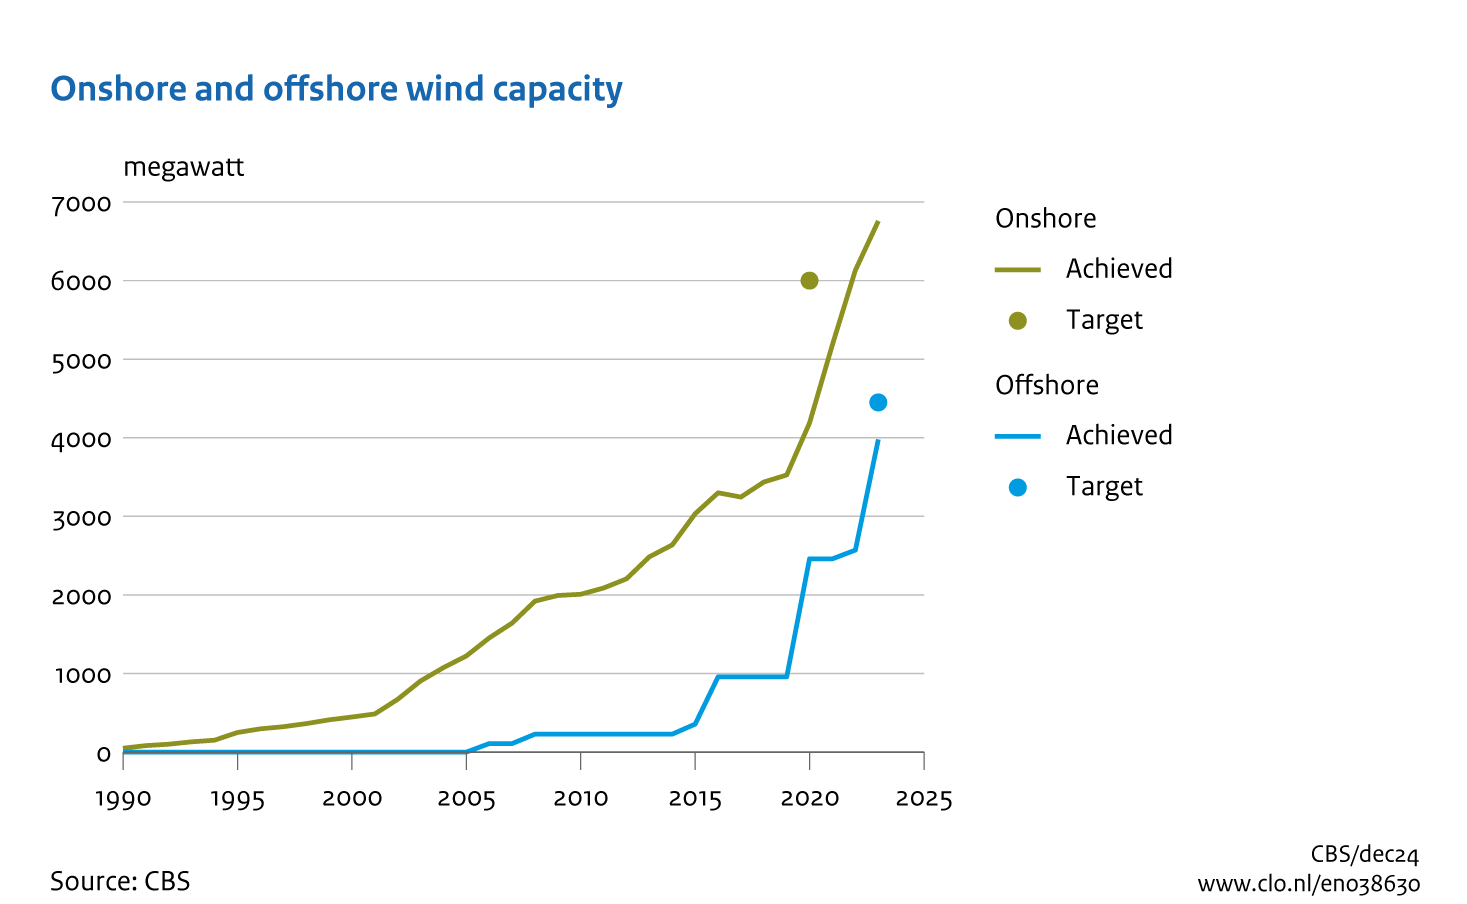

*(Source: CBS/PBL)*

Notice the clear and significant **upward trend** in both the green (Onshore) and blue (Offshore) capacity lines, especially from 2015 onwards. This means the maximum possible power generation (the installed capacity) has been constantly increasing.

Trying to predict the absolute power generation (in Megawatts) directly is like trying to hit a target that's constantly moving further away. The model needs to predict variations caused by *weather*, but the raw data is heavily influenced by this *increasing capacity trend*. This trend makes the raw power data **non-stationary**.

**Initial Attempts & Why They Failed:**

When we first started building this forecasting model, we initially tried predicting the absolute MW values directly without accounting for this capacity growth. The results were poor. The model struggled to differentiate between changes in generation due to weather fluctuations and changes due simply to more turbines being available. It couldn't learn effectively because the underlying baseline it was trying to predict was constantly rising.

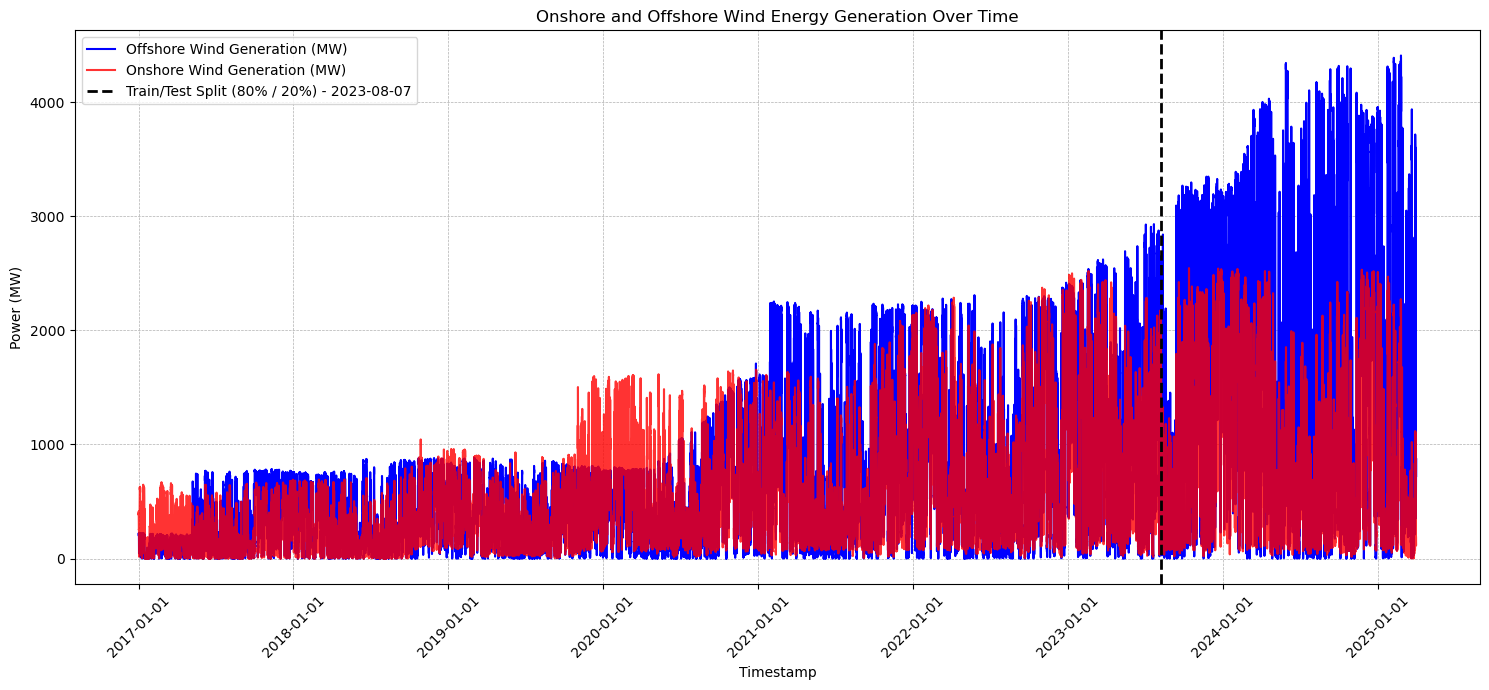



As we can see from our dataset, there's a clear uptrend of energy production, specially after our cut-off for the test-set (data unseen by the model)


**The Solution: Normalization via Capacity Proxy**

To solve this, we need to remove the effect of the changing capacity from the target variable. We do this by:

1.  **Estimating Capacity:** Since I coulnd't find precise installed capacity data, I had to create a **proxy** for it. We calculate the *maximum power observed* over a rolling 365-day window (`.rolling(window='365D').max()`). This rolling max (the `capacity_proxy`) adapts over time, roughly tracking the increasing trend seen in the graph.
2.  **Normalizing the Target:** We then divide the *actual* power generated at each moment by this `capacity_proxy`. Instead of predicting absolute MW, the model now learns to predict the **capacity utilization factor** – a value typically between 0 and 1 representing what *fraction* of the estimated available capacity is being used, driven by weather conditions.

This normalization effectively **detrends** the target variable, making it more stationary and allowing the model to focus purely on learning the relationship between weather features and the *proportion* of wind power generated.

---

**Why is this Necessary? (Summary)**

* **(Addresses Graph Trend):** Directly tackles the non-stationarity caused by increasing capacity shown in the graph.
* **(Improves Model Learning):** Allows the model to learn the weather-to-power relationship on a stable, normalized scale (0-1) instead of chasing a rising absolute value. Essential for good performance, as initial attempts proved.
* **(Practical Proxy):** Uses observed data (rolling max) as a feasible proxy when exact, real-time capacity figures aren't available.


Capacity proxy calculated using 365D window.
Created 'Offshore_Norm'


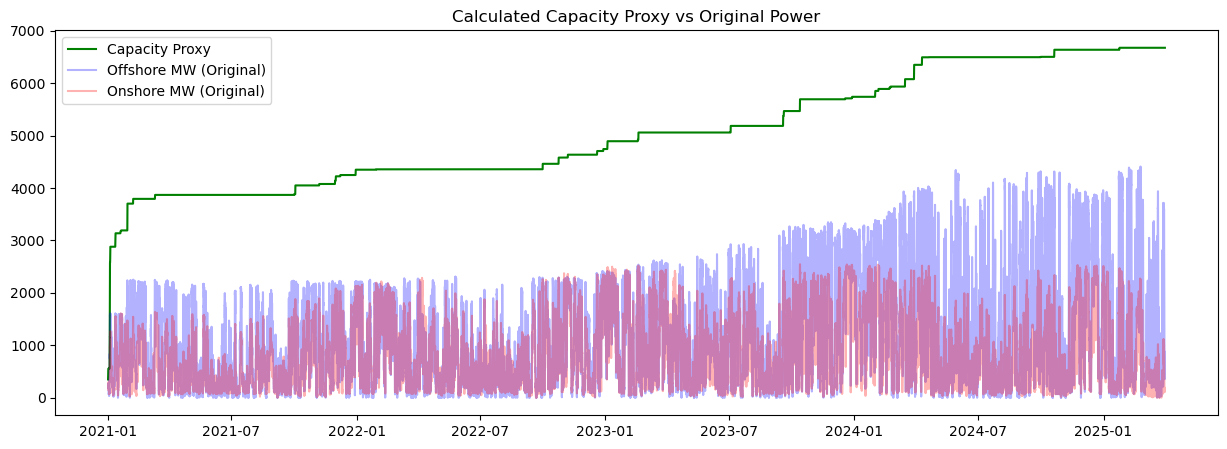

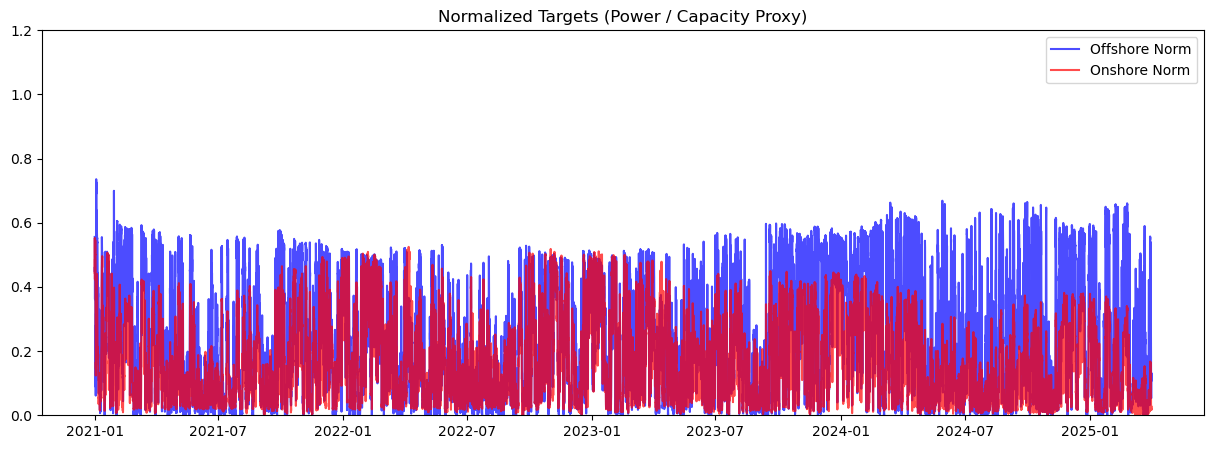

In [73]:
# <<< --- START: CAPACITY PROXY CALCULATION AND NORMALIZATION --- >>>

# STEP 1: Determine the base column for the proxy calculation.
# It's better to use the total power if available, as it reflects the whole system's potential peak.
if 'Wind_Offshore_MW' in final_df.columns and 'Wind_Onshore_MW' in final_df.columns:
    final_df['Total_Wind_MW'] = final_df['Wind_Offshore_MW'] + final_df['Wind_Onshore_MW']
    # Use this new 'Total_Wind_MW' column as the base for calculating the rolling maximum.
    proxy_base_col = 'Total_Wind_MW'
else:
    raise ValueError("Error: Cannot find 'Wind_Offshore_MW' or 'Wind_Onshore_MW' to calculate proxy.")

# STEP 2: Calculate the rolling maximum capacity proxy.
window = '365D' #This can be changed; 
# For each timestamp, look back over the defined 'window' in the 'proxy_base_col'.
# Find the maximum value observed within that window.
# 'min_periods=1' ensures a value is calculated even at the start before a full window is available.
final_df['capacity_proxy'] = final_df[proxy_base_col].rolling(window=window, min_periods=1).max()

# STEP 3: Handle potential missing values in the proxy.
# '.rolling().max()' might produce NaNs if input data has issues, or '.ffill()' handles initial periods.
# Forward fill: Propagate the last valid proxy value forward to fill gaps.
# Backward fill: Fill any remaining NaNs at the very beginning using the first valid value.
final_df['capacity_proxy'] = final_df['capacity_proxy'].ffill().bfill()

# STEP 4: Add a small epsilon for numerical stability.
# Define a very small positive number.
epsilon = 1e-6
# Add this epsilon to the proxy value. This prevents division by zero errors in the next step
# if the 'capacity_proxy' happens to be exactly 0 at any point.
final_df['capacity_proxy'] = final_df['capacity_proxy'] + epsilon
print(f"Capacity proxy calculated using {window} window.")


# STEP 6: Create the NORMALIZED target columns.
if 'Wind_Offshore_MW' in final_df.columns:
    # Divide the actual offshore power generation at each timestamp by the calculated capacity proxy for that timestamp.
    # The result is a ratio representing the proportion of estimated capacity being utilized.
    # '.clip(0, 1.1)' limits the normalized value between 0 and 1.1 (allowing slightly above 1).
    final_df['Offshore_Norm'] = (final_df['Wind_Offshore_MW'] / final_df['capacity_proxy']).clip(0, 1.1)
    print("Created 'Offshore_Norm'") # Confirmation message
if 'Wind_Onshore_MW' in final_df.columns:
    # Perform the same normalization for the onshore power generation.
    final_df['Onshore_Norm'] = (final_df['Wind_Onshore_MW'] / final_df['capacity_proxy']).clip(0, 1.1)

# STEP 7: Visualize the results.

# First plot: Show the calculated proxy against the original power generation.
plt.figure(figsize=(15, 5)) # Create a figure for the plot
# Plot the capacity proxy line (green).
if 'capacity_proxy' in final_df.columns:
    plt.plot(final_df.index, final_df['capacity_proxy'], label='Capacity Proxy', color='green')
if 'Wind_Offshore_MW' in final_df.columns:
    plt.plot(final_df.index, final_df['Wind_Offshore_MW'], label='Offshore MW (Original)', color='blue', alpha=0.3)
if 'Wind_Onshore_MW' in final_df.columns:
    plt.plot(final_df.index, final_df['Wind_Onshore_MW'], label='Onshore MW (Original)', color='red', alpha=0.3)
plt.title('Calculated Capacity Proxy vs Original Power') 
plt.legend() 
plt.show()

# Second plot: Show the newly created NORMALIZED target variables.
plt.figure(figsize=(15, 5)) # Create a second figure
# Plot the normalized offshore power (blue).
if 'Offshore_Norm' in final_df.columns:
    plt.plot(final_df.index, final_df['Offshore_Norm'], label='Offshore Norm', color='blue', alpha=0.7)
# Plot the normalized onshore power (red).
if 'Onshore_Norm' in final_df.columns:
    plt.plot(final_df.index, final_df['Onshore_Norm'], label='Onshore Norm', color='red', alpha=0.7)
plt.title('Normalized Targets (Power / Capacity Proxy)') # Set plot title
plt.legend() # Display the legend
# Set the y-axis limits to focus on the typical 0-1 range, plus a small margin.
plt.ylim(0, 1.2)
plt.show() # Show the second plot


## Adding Lagged Target Features (e.g., `Offshore_Norm_Lag1H`)

**1. The Problem: Strong Persistence Baseline**

* Our baseline analysis revealed a critical insight: a very simple **1-Hour Persistence model** (which predicts that the power at the current hour `t` will be the same as the power at the previous hour `t-1H`) achieved a surprisingly strong performance (MAE ≈ 108.7 MW, RMSE ≈ 174.0 MW).
* This strong performance is common in time series like wind power due to high **autocorrelation** – the value now is highly dependent on the value very recently. Weather conditions often persist hour-to-hour.
* The previous TCN model, despite using various weather features and handling the long-term capacity trend via normalization (using the `capacity_proxy`), struggled to significantly outperform this simple baseline (previous TCN MAE was ≈ 341 MW). This indicated the model wasn't effectively capturing the crucial short-term persistence information.

**2. The Solution: Giving the Model the Baseline Information Directly**

* To address this, we explicitly added the actual normalized power value from the previous hour (`t-1H`) directly as an **input feature** for predicting the value at the current hour (`t`).
* **How:** We used the pandas `.shift(1)` function on the `Offshore_Norm` and `Onshore_Norm` columns (after they were created) to generate new columns (`Offshore_Norm_Lag1H`, `Onshore_Norm_Lag1H`). These new columns were then included in the feature set `X` fed into the TCN model.

**3. Why It Works: Learning Deviations from Persistence**

* By providing the `Power_Norm(t-1H)` value as input, we essentially give the TCN model the **same powerful starting point** used by the highly effective 1H persistence baseline.
* The TCN no longer needs to try and infer this simple hour-to-hour persistence relationship solely from complex weather patterns.
* Instead, the model can now focus its learning capacity on a more nuanced task: learning **how the *other* input features** (wind speed, direction, temperature, etc., over the `SEQUENCE_LENGTH` window) cause the actual power at time `t` to deviate from the already known value at `t-1H`.
* It learns to make adjustments or predict the change relative to the previous hour, informed by the weather context.

**4. The Impact: Significant Performance Improvement**

* As seen in the evaluation results , adding this lagged feature dramatically improved the TCN's performance:
    * MAE dropped significantly from ~341 MW to **~123 MW**.
    * RMSE dropped significantly from ~474 MW to **~174 MW**.
* The TCN now performs **competitively** with the strong 1H persistence baseline (MAE is slightly higher, but RMSE is now slightly *lower*, suggesting fewer large errors).


In [93]:
# ADD LAGGED TARGET FEATURES  >>>
print("\nAdding lagged normalized targets as features...")
lag_hours = 1 # Define the lag (1 hour)
lag_col_offshore = f'Offshore_Norm_Lag{lag_hours}H'
lag_col_onshore = f'Onshore_Norm_Lag{lag_hours}H'

# Create shifted columns
if 'Offshore_Norm' in final_df.columns:
    final_df[lag_col_offshore] = final_df['Offshore_Norm'].shift(lag_hours)
if 'Onshore_Norm' in final_df.columns:
    final_df[lag_col_onshore] = final_df['Onshore_Norm'].shift(lag_hours)

# The first 'lag_hours' rows will now have NaN for these new columns.
# We will handle these NaNs *after* the train/test split to avoid data leakage.
print(f"NaNs introduced by shift: {final_df[[lag_col_offshore, lag_col_onshore]].isnull().sum().sum()}")



Adding lagged normalized targets as features...
NaNs introduced by shift: 2


In [97]:
#  3. Separate Initial Features (X) and Targets (y) 
print("\n--- 3. Separating Initial Features and Targets ---")

# Use the normalized target columns 
target_cols = []
if 'Offshore_Norm' in final_df.columns: target_cols.append('Offshore_Norm')
if 'Onshore_Norm' in final_df.columns: target_cols.append('Onshore_Norm')
print(f"Using target columns: {target_cols}")


# Exclude original targets, total, proxy, AND normalized targets from features 
cols_to_exclude_from_features = [
    'Wind_Offshore_MW', 'Wind_Onshore_MW', # Original targets
    'Total_Wind_MW', # Calculated total
    'capacity_proxy', # Calculated proxy
] + target_cols # Also exclude the NEW normalized targets

all_feature_cols = [col for col in final_df.columns if col not in cols_to_exclude_from_features]

print(f"Excluding {len(cols_to_exclude_from_features)} columns from features: {cols_to_exclude_from_features}")

X_initial = final_df[all_feature_cols]
y = final_df[target_cols] # <<< Uses the normalized targets now

print(f"Initial features (X_initial) shape: {X_initial.shape}")
print(f"Targets (y) shape: {y.shape} - Using Normalized Targets")
if X_initial.isnull().sum().sum() > 0: print("Warning: NaNs found in X_initial features!")


--- 3. Separating Initial Features and Targets ---
Using target columns: ['Offshore_Norm', 'Onshore_Norm']
Excluding 6 columns from features: ['Wind_Offshore_MW', 'Wind_Onshore_MW', 'Total_Wind_MW', 'capacity_proxy', 'Offshore_Norm', 'Onshore_Norm']
Initial features (X_initial) shape: (37226, 46)
Targets (y) shape: (37226, 2) - Using Normalized Targets


In [99]:
# 4. Feature Selection 
print("\n--- 4. Performing Feature Selection ---")
#These features have been removed, even after processing the data, because there was a high correlation between then and I also wanted to reduce the number of features (it was too complex at first, overfitting a lot)
cols_to_remove = [
    'hour_sin_onshore', 'hour_cos_onshore', 'day_of_week_sin_onshore', 'day_of_week_cos_onshore',
    'day_of_year_sin_onshore', 'day_of_year_cos_onshore', 'month_sin_offshore', 'month_cos_offshore',
    'month_sin_onshore', 'month_cos_onshore', 'wind_direction_10m_sin_offshore', 'wind_direction_10m_cos_offshore',
    'wind_direction_10m_sin_onshore', 'wind_direction_10m_cos_onshore', 'wind_speed_10m_offshore',
    'wind_gusts_10m_offshore', 'wind_speed_10m_onshore', 'wind_gusts_10m_onshore', 'surface_pressure_onshore',
    'cloud_cover_low_offshore', 'cloud_cover_mid_offshore', 'cloud_cover_high_offshore', 'cloud_cover_low_onshore',
    'cloud_cover_mid_onshore', 'cloud_cover_high_onshore'
]
cols_to_remove = sorted(list(set(cols_to_remove)))
print(f"Removing {len(cols_to_remove)} features.")
selected_feature_cols = [col for col in X_initial.columns if col not in cols_to_remove]
X = X_initial[selected_feature_cols].copy()
NUM_FEATURES = X.shape[1] # <<<--- FINAL FEATURE COUNT
NUM_OUTPUTS = y.shape[1]
print(f"Selected {NUM_FEATURES} features for modeling.")
print(f"Shape of final features (X): {X.shape}")


--- 4. Performing Feature Selection ---
Removing 25 features.
Selected 21 features for modeling.
Shape of final features (X): (37226, 21)


In [101]:
print(f"\nSelected {NUM_FEATURES} features for modeling:")
# print(X.columns.tolist()) # Uncomment to see the final list
print(f"Shape of final features (X): {X.shape}")

# TO SAVE new final dataset
print("\n--- Saving Selected Features ---")
output_filename = "selected_features.csv"
X.to_csv(output_filename, index=True)
print(f"Successfully saved selected features (DataFrame X) to '{output_filename}'")



Selected 21 features for modeling:
Shape of final features (X): (37226, 21)

--- Saving Selected Features ---
Successfully saved selected features (DataFrame X) to 'selected_features.csv'


In [104]:
df = pd.read_csv("selected_features.csv")
print(df.columns.to_list())

['Timestamp', 'wind_speed_100m_offshore', 'surface_pressure_offshore', 'temperature_2m_offshore', 'relative_humidity_2m_offshore', 'rain_offshore', 'hour_sin_offshore', 'hour_cos_offshore', 'day_of_week_sin_offshore', 'day_of_week_cos_offshore', 'day_of_year_sin_offshore', 'day_of_year_cos_offshore', 'wind_direction_100m_sin_offshore', 'wind_direction_100m_cos_offshore', 'wind_speed_100m_onshore', 'temperature_2m_onshore', 'relative_humidity_2m_onshore', 'rain_onshore', 'wind_direction_100m_sin_onshore', 'wind_direction_100m_cos_onshore', 'Offshore_Norm_Lag1H', 'Onshore_Norm_Lag1H']


In [106]:
# Train/Test Split (BEFORE SCALING) 
print("\n--- 5. Splitting Data (Train/Test) ---")
num_samples = len(X)
split_index = int(num_samples * (1 - VALIDATION_SPLIT_FRAC))
X_train_df, y_train_df = X[:split_index], y[:split_index]
X_test_df, y_test_df = X[split_index:], y[split_index:]
print(f"X_train_df shape: {X_train_df.shape}, y_train_df shape: {y_train_df.shape}")
print(f"X_test_df shape: {X_test_df.shape}, y_test_df shape: {y_test_df.shape}")
if not X_train_df.empty and not X_test_df.empty: assert X_train_df.index.max() < X_test_df.index.min()


--- 5. Splitting Data (Train/Test) ---
X_train_df shape: (29780, 21), y_train_df shape: (29780, 2)
X_test_df shape: (7446, 21), y_test_df shape: (7446, 2)


In [108]:
#  6. Scaling Data (Fit ONLY on Train) 
# Handle NaNs in lagged features created by shift ONLY in the training set.
# The first row(s) of X_train_df will have NaNs due to the .shift() operation.
# We drop these rows to prevent issues with scaling and training.
lag_hours = 1 #  This has to match the lag used earlier
lag_cols_in_train = [col for col in X_train_df.columns if f'_Lag{lag_hours}H' in col]

if lag_cols_in_train and X_train_df[lag_cols_in_train].isnull().any().any():
    print(f"\nHandling NaNs in lagged features for training set: {lag_cols_in_train}")
    original_train_len = len(X_train_df)
    # Get index of rows *without* NaNs in the specified lag columns
    valid_index = X_train_df.dropna(subset=lag_cols_in_train).index
    X_train_df = X_train_df.loc[valid_index]
    y_train_df = y_train_df.loc[valid_index]
    print(f"Removed {original_train_len - len(X_train_df)} initial rows from training set due to lagged feature NaNs.")

else:
    print("\nNo NaNs found in lagged training features or no lagged features present. Skipping NaN handling.")

print(f"\n--- 6. Scaling Data (using {SCALER_TYPE}) ---")
if SCALER_TYPE == 'RobustScaler': scaler_x, scaler_y = RobustScaler(), RobustScaler()
else: scaler_x, scaler_y = StandardScaler(), StandardScaler()
print(f"Using {scaler_x.__class__.__name__}.")

print("Fitting scalers on TRAINING data only...")
X_train_scaled = scaler_x.fit_transform(X_train_df)
y_train_scaled = scaler_y.fit_transform(y_train_df)
print("Transforming TEST data using fitted scalers...")
X_test_scaled = scaler_x.transform(X_test_df)
y_test_scaled = scaler_y.transform(y_test_df)
print("Data scaling complete.")
print(f"Shapes: X_train_scaled {X_train_scaled.shape}, y_train_scaled {y_train_scaled.shape}, X_test_scaled {X_test_scaled.shape}, y_test_scaled {y_test_scaled.shape}")

scaler_x_path = f"scaler_x_{NUM_FEATURES}feat_{SCALER_TYPE}.joblib"
scaler_y_path = f"scaler_y_{NUM_FEATURES}feat_{SCALER_TYPE}.joblib"
joblib.dump(scaler_x, scaler_x_path); joblib.dump(scaler_y, scaler_y_path)
print(f"Fitted scalers saved.")


Handling NaNs in lagged features for training set: ['Offshore_Norm_Lag1H', 'Onshore_Norm_Lag1H']
Removed 1 initial rows from training set due to lagged feature NaNs.

--- 6. Scaling Data (using RobustScaler) ---
Using RobustScaler.
Fitting scalers on TRAINING data only...
Transforming TEST data using fitted scalers...
Data scaling complete.
Shapes: X_train_scaled (29779, 21), y_train_scaled (29779, 2), X_test_scaled (7446, 21), y_test_scaled (7446, 2)
Fitted scalers saved.


In [112]:
# 7. Creating Sequences
# This step reshapes the data into a format suitable for sequence models like TCN, LSTM, or GRU.
# These models learn from sequences of past observations to predict the next value(s).
print("\n--- 7. Creating Sequences ---")

def create_sequences(X_data, y_data, sequence_length):
    # Initialize empty lists to store the generated sequences and their corresponding targets.
    X_seq_list, y_seq_list = [], []

    # Determine the number of sequences that can be created.
    num_possible_sequences = len(X_data) - sequence_length

    try:
        from tqdm import trange # Import tqdm's range function
        # Create an iterator with a progress bar.
        iterator = trange(num_possible_sequences, desc="Creating sequences")
    # If tqdm is not installed or fails to import, fall back to the standard Python range.
    except ImportError:
        iterator = range(num_possible_sequences) # Standard iterator without progress bar

    # Iterate through the data using a sliding window.
    for i in iterator:
        # Extract a sequence of features:
        # Start at index 'i' and take 'sequence_length' consecutive time steps from X_data.
        # Shape of sequence: (sequence_length, num_features)
        sequence = X_data[i : i + sequence_length]
        # Append this feature sequence to the list of input sequences.
        X_seq_list.append(sequence)

        # Extract the corresponding target value:
        # The target is the value(s) in y_data at the *end* of the current sequence window.
        # The sequence ends at index 'i + sequence_length - 1'.
        # Shape of target: (num_outputs,)
        target = y_data[i + sequence_length - 1]
        # Append this target value to the list of targets.
        y_seq_list.append(target)

    # Check if any sequences were actually created (handles edge case of short input data).
    if not X_seq_list or not y_seq_list:
        print("\nError: No sequences created. Input data might be shorter than sequence_length.")
        return None, None # Return None if sequence creation failed

    # Convert the lists of sequences and targets into NumPy arrays for efficient processing by the model.
    # X_seq will have shape: (num_sequences, sequence_length, num_features)
    # y_seq will have shape: (num_sequences, num_outputs)
    return np.array(X_seq_list), np.array(y_seq_list)


# Create training sequences from the scaled training data.
# X_train_scaled/y_train_scaled should be NumPy arrays from the scaling step.
# SEQUENCE_LENGTH is was defined earlier
X_train_seq, y_train_seq = create_sequences(X_train_scaled, y_train_scaled, SEQUENCE_LENGTH)

# Create testing sequences from the scaled testing data.
X_test_seq, y_test_seq = create_sequences(X_test_scaled, y_test_scaled, SEQUENCE_LENGTH)


# Print the shapes of the resulting sequence arrays to verify the transformation.
print(f"\nSequence shapes: "
      f"X_train_seq {X_train_seq.shape}, y_train_seq {y_train_seq.shape}, "
      f"X_test_seq {X_test_seq.shape}, y_test_seq {y_test_seq.shape}")

# Example interpretation of X_train_seq.shape (e.g., (20000, 24, 15)):
# - 20000 sequences were created for training.
# - Each input sequence looks back 24 time steps (SEQUENCE_LENGTH).
# - Each time step in the sequence has 15 features (NUM_FEATURES).
# Example interpretation of y_train_seq.shape (e.g., (20000, 2)):
# - 20000 corresponding target values.
# - Each target has 2 output values (NUM_OUTPUTS, e.g., Offshore_Norm, Onshore_Norm).



--- 7. Creating Sequences ---


Creating sequences: 100%|████████████████████████████████████████| 7422/7422 [00:00<00:00, 2080056.41it/s]


Sequence shapes: X_train_seq (29755, 24, 21), y_train_seq (29755, 2), X_test_seq (7422, 24, 21), y_test_seq (7422, 2)


In [90]:
# 8. TCN Model Definition 

# function to create and compile the TCN model architecture.
def create_tcn_regression_model(input_shape, num_outputs, nb_filters, kernel_size, dilations, nb_stacks,
                                padding='causal', use_skip_connections=True, return_sequences=False,
                                dropout_rate=0.0, activation='relu',
                                kernel_initializer='he_normal', use_batch_norm=True, use_layer_norm=False,
                                use_l2_reg=False, l2_factor=0.001,
                                opt='adam', lr=0.002, model_name='tcn_regression_model'):

    # Define the input layer, specifying the shape of input sequences.
    input_layer = Input(shape=input_shape, name="Input_Layer")

    # Define the main TCN layer using the specified hyperparameters.
    # This layer processes the input sequences using dilated causal convolutions.
    tcn_layer = TCN(nb_filters=nb_filters, kernel_size=kernel_size, nb_stacks=nb_stacks,
                    dilations=dilations, padding=padding, use_skip_connections=use_skip_connections,
                    dropout_rate=dropout_rate, return_sequences=return_sequences, activation=activation,
                    kernel_initializer=kernel_initializer, use_batch_norm=use_batch_norm,
                    use_layer_norm=use_layer_norm, name=model_name)(input_layer) # Pass the input layer to the TCN layer

    # --- Define Output Layer for Regression ---
    # Set up L2 regularization for the output Dense layer's weights if specified.
    output_regularizer = l2(l2_factor) if use_l2_reg else None
    print(f"Configuring Regression TCN. Output L2 Reg: {'Enabled (factor={})'.format(l2_factor) if use_l2_reg else 'Disabled'}")

    # Add a Dense (fully connected) layer to map the TCN output to the desired number of outputs.
    # Apply L2 regularization to the kernel weights if enabled.
    dense_output = Dense(num_outputs, name="Dense_Output_Regressor",
                         kernel_regularizer=output_regularizer)(tcn_layer) # Connect Dense layer to TCN output

    # Apply a linear activation function for the final output layer.
    # This is standard for regression tasks, as we want to predict continuous values without constraints.
    output_layer = Activation('linear', name="Linear_Output")(dense_output)

    # Create and Compile the Model 
    # Define the Keras Model 
    model = Model(input_layer, output_layer, name=f"{model_name}_Compiled")

    # Select the optimizer based on the 'opt' parameter.
    if opt.lower() == 'adam':
        # Adam optimizer with learning rate and gradient clipping (clipnorm).
        optimizer = tf.keras.optimizers.Adam(learning_rate=lr, clipnorm=1.0)
    elif opt.lower() == 'rmsprop':
        # RMSprop optimizer with learning rate and gradient clipping.
        optimizer = tf.keras.optimizers.RMSprop(learning_rate=lr, clipnorm=1.0)
    else:
        # Default to Adam if the specified optimizer is not recognized.
        print(f"Optimizer '{opt}' not recognized, defaulting to Adam.")
        optimizer = tf.keras.optimizers.Adam(learning_rate=lr, clipnorm=1.0)

    # Define the loss function and metrics for regression.
    # 'mean_squared_error' (MSE) is a common loss function for regression.
    # 'mae' (Mean Absolute Error) and 'mse' are tracked as metrics during training.
    loss_func = 'mean_squared_error'
    metrics = ['mae', 'mse']

    # Compile the model with the chosen optimizer, loss function, and metrics.
    model.compile(optimizer=optimizer, loss=loss_func, metrics=metrics)
    print(f"Model compiled with Loss: {loss_func}, Metrics: {metrics}, Optimizer LR: {lr}")

    # Return the compiled model.
    return model

# Instantiate the Model 
# Provide the specific hyperparameter values 
# NUM_FEATURES, SEQUENCE_LENGTH, NUM_OUTPUTS, TCN_NUM_FILTERS, TCN_KERNEL_SIZE, etc.

print(f"Creating TCN regression model with NUM_FEATURES = {NUM_FEATURES}...")
your_tcn_model = create_tcn_regression_model(
    input_shape=(SEQUENCE_LENGTH, NUM_FEATURES), # Shape from sequence creation
    num_outputs=NUM_OUTPUTS,                     # Number of target variables (e.g., 2 for Offshore/Onshore)
    nb_filters=TCN_NUM_FILTERS,                  # TCN hyperparameter
    kernel_size=TCN_KERNEL_SIZE,                 # TCN hyperparameter
    dilations=TCN_DILATIONS,                     # TCN hyperparameter
    nb_stacks=TCN_NUM_STACKS,                    # TCN hyperparameter
    padding=PADDING,                             # TCN hyperparameter ('causal')
    use_skip_connections=USE_SKIP_CONNECTIONS,   # TCN hyperparameter
    return_sequences=RETURN_SEQUENCES,           # TCN hyperparameter (False for final prediction)
    dropout_rate=TCN_DROPOUT_RATE,               # Regularization hyperparameter
    activation=ACTIVATION,                       # TCN hyperparameter ('relu')
    use_l2_reg=USE_L2_REG,                       # Regularization hyperparameter
    l2_factor=L2_FACTOR,                         # Regularization hyperparameter
    opt='adam',                                  # Optimizer choice
    lr=LEARNING_RATE,                            # Learning rate
    model_name=f'TCN_{NUM_FEATURES}Feat_Reg'     
)

# --- Print Model Summary ---
# Display the layers, output shapes, and number of parameters in the created model.
print("\nModel Summary:")
your_tcn_model.summary()

Creating TCN model with NUM_FEATURES = 21...
Configuring Regression TCN. Output L2 Reg: <keras.src.regularizers.regularizers.L2 object at 0x308ce7e60>
Model compiled with Loss: mean_squared_error, Metrics: ['mae', 'mse'], Optimizer LR: 0.0005

Model Summary:


Model: "TCN_21Feat_Reg_Compiled"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Input_Layer (InputLayer)        │ (None, 24, 21)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ TCN_21Feat_Reg (TCN)            │ (None, 16)             │       127,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dense_Output_Regressor (Dense)  │ (None, 2)              │            34 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Linear_Output (Activation)      │ (None, 2)              │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 127,426 (497.76 KB)

 Trainable params: 126,146 (492.76 KB)

 Non-trainable params: 1,280 (5.00 KB)

In [16]:
# 9. Model Training
# Define the filename for saving the best model
model_filename = f'best_tcn_model_{NUM_FEATURES}feat_reg.keras'


# Stop training early if validation loss doesn't improve for 'patience' epochs
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1)

# Save the model weights only when validation loss improves
model_checkpoint = ModelCheckpoint(filepath=model_filename, monitor='val_loss', save_best_only=True, verbose=1)

# Reduce learning rate when validation loss plateaus
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=4, min_lr=0.00001, verbose=1)
print("Using ReduceLROnPlateau scheduler.")

# Use TQDM progress bar for training epochs 
try:
    
    from tqdm.keras import TqdmCallback
    tqdm_callback = TqdmCallback(verbose=1)
    fit_verbose = 0 # Use TQDM's progress bar
    callbacks_list = [early_stopping, model_checkpoint, reduce_lr, tqdm_callback]
except ImportError: #If don't have/can
    fit_verbose = 1 # Use Keras' default progress bar
    callbacks_list = [early_stopping, model_checkpoint, reduce_lr]


#  Train the Model 
# The 'fit' method trains the model on the training sequences
history = your_tcn_model.fit(
    X_train_seq,                # Input training sequences
    y_train_seq,                # Target training sequences
    epochs=EPOCHS,              # Number of training epochs 
    batch_size=BATCH_SIZE,      # Number of samples per gradient update 
    validation_data=(X_test_seq, y_test_seq), # Data to evaluate loss and metrics on after each epoch
    callbacks=callbacks_list,   # List of callbacks to apply during training
    verbose=fit_verbose         
)



--- 9. Starting Model Training ---
Using ReduceLROnPlateau scheduler.


0epoch [00:00, ?epoch/s]

0batch [00:00, ?batch/s]

Using TQDM progress bar.

Epoch 1: val_loss improved from inf to 0.24909, saving model to best_tcn_model_21feat_reg.keras

Epoch 2: val_loss improved from 0.24909 to 0.12245, saving model to best_tcn_model_21feat_reg.keras

Epoch 3: val_loss improved from 0.12245 to 0.09369, saving model to best_tcn_model_21feat_reg.keras

Epoch 4: val_loss improved from 0.09369 to 0.07900, saving model to best_tcn_model_21feat_reg.keras

Epoch 5: val_loss improved from 0.07900 to 0.06935, saving model to best_tcn_model_21feat_reg.keras

Epoch 6: val_loss improved from 0.06935 to 0.06442, saving model to best_tcn_model_21feat_reg.keras

Epoch 7: val_loss improved from 0.06442 to 0.05580, saving model to best_tcn_model_21feat_reg.keras

Epoch 8: val_loss improved from 0.05580 to 0.04597, saving model to best_tcn_model_21feat_reg.keras

Epoch 9: val_loss improved from 0.04597 to 0.04111, saving model to best_tcn_model_21feat_reg.keras

Epoch 10: val_loss improved from 0.04111 to 0.03640, saving model to 

In [17]:
#  10. Evaluation and Prediction 
print("\n--- 10. Evaluating Model and Making Predictions ---")
# This evaluation is on the SCALED NORMALIZED targets
scaled_evaluation = your_tcn_model.evaluate(X_test_seq, y_test_seq, batch_size=BATCH_SIZE * 2, verbose=0)
print(f"Scaled Normalized Test Loss (MSE): {scaled_evaluation[0]:.4f}") # Loss on normalized scale
if len(scaled_evaluation) > 1: print(f"Scaled Normalized Test MAE: {scaled_evaluation[1]:.4f}")
if len(scaled_evaluation) > 2: print(f"Scaled Normalized Test MSE (from metrics): {scaled_evaluation[2]:.4f}")

print("\nMaking predictions on test set (output is scaled normalized power)...")
scaled_normalized_predictions = your_tcn_model.predict(X_test_seq, batch_size=BATCH_SIZE * 2)

# --- INVERSE TRANSFORM ---
# 1. Inverse transform the SCALED NORMALIZED predictions -> NORMALIZED predictions
normalized_predictions = scaler_y.inverse_transform(scaled_normalized_predictions)

# 2. Get the capacity proxy values corresponding to the TEST set targets
# Need the proxy values that align with y_test_seq
# First, get the original capacity proxy for the entire test period
capacity_proxy_test_period = final_df.loc[X_test_df.index, 'capacity_proxy'] # Get proxy for the original test df range

# Create sequences for the capacity proxy, matching y_test_seq
# We need the proxy value at the *end* of each sequence window, just like the target
capacity_proxy_test_seq = []
for i in range(len(capacity_proxy_test_period) - SEQUENCE_LENGTH):
     # Get the proxy value at the end of the sequence window used for y_test_seq[i]
     capacity_proxy_test_seq.append(capacity_proxy_test_period.iloc[i + SEQUENCE_LENGTH - 1])
capacity_proxy_test_seq = np.array(capacity_proxy_test_seq).reshape(-1, 1) # Reshape to (num_sequences, 1)

if normalized_predictions.shape[0] != capacity_proxy_test_seq.shape[0]:
     print(f"Error: Shape mismatch between predictions ({normalized_predictions.shape[0]}) and test capacity proxy ({capacity_proxy_test_seq.shape[0]}). Check sequence creation alignment.")
     # Fallback or exit needed here. Using minimum length for now, but indicates an issue.
     min_len = min(normalized_predictions.shape[0], capacity_proxy_test_seq.shape[0])
     normalized_predictions = normalized_predictions[:min_len]
     capacity_proxy_test_seq = capacity_proxy_test_seq[:min_len]
     print(f"Warning: Truncated predictions and proxy to minimum length: {min_len}")


# 3. Convert NORMALIZED predictions to ACTUAL SCALE (MW) predictions
# Multiply normalized prediction by the capacity proxy for that timestep
# Handle epsilon added earlier by subtracting it if needed, although direct multiplication is usually fine.
actual_scale_predictions = normalized_predictions * capacity_proxy_test_seq

# 4. Get the ORIGINAL actual scale targets for comparison
# Inverse transform the SCALED NORMALIZED y_test_seq -> NORMALIZED y_test_seq
normalized_y_test = scaler_y.inverse_transform(y_test_seq[:len(actual_scale_predictions)]) # Match length if truncated
# Convert NORMALIZED y_test -> ACTUAL y_test
actual_scale_y_test = normalized_y_test * capacity_proxy_test_seq[:len(actual_scale_predictions)] # Match length if truncated



# Now calculate metrics on the ACTUAL SCALE values
mae_actual = mean_absolute_error(actual_scale_y_test, actual_scale_predictions)
mse_actual = mean_squared_error(actual_scale_y_test, actual_scale_predictions)
rmse_actual = np.sqrt(mse_actual)
print(f"\n--- Performance on Actual Scale (Test Set) ---")
print(f"Mean Absolute Error (MAE): {mae_actual:.2f} MW")
print(f"Mean Squared Error (MSE):  {mse_actual:.2f} MW^2") 
print(f"Root Mean Squared Error (RMSE): {rmse_actual:.2f} MW")

print("\nFirst 5 Actual Scale Predictions vs Targets:")
original_target_names = ['Offshore', 'Onshore'] 
for i in range(min(5, len(actual_scale_predictions))):
    pred_str = f"Pred {original_target_names[0]}={actual_scale_predictions[i, 0]:.1f}"
    actual_str = f"Actual {original_target_names[0]}={actual_scale_y_test[i, 0]:.1f}"
    if actual_scale_predictions.shape[1] > 1: 
        pred_str += f", Pred {original_target_names[1]}={actual_scale_predictions[i, 1]:.1f}"
        actual_str += f", Actual {original_target_names[1]}={actual_scale_y_test[i, 1]:.1f}"
    print(f"Sample {i+1}: {pred_str} || {actual_str}")


--- 10. Evaluating Model and Making Predictions ---
Evaluating on scaled test data (using potentially restored best weights)...
Scaled Normalized Test Loss (MSE): 0.0091
Scaled Normalized Test MAE: 0.0687
Scaled Normalized Test MSE (from metrics): 0.0087

Making predictions on test set (output is scaled normalized power)...
45/45 ━━━━━━━━━━━━━━━━━━━━ 4s 60ms/step
Inverse transforming predictions AND getting corresponding capacity proxy...

--- Performance on Actual Scale (Test Set) ---
Mean Absolute Error (MAE): 122.98 MW
Mean Squared Error (MSE):  30143.82 MW^2
Root Mean Squared Error (RMSE): 173.62 MW

First 5 Actual Scale Predictions vs Targets:
Sample 1: Pred Offshore=2092.5, Pred Onshore=527.0 || Actual Offshore=2086.0, Actual Onshore=461.5
Sample 2: Pred Offshore=1911.1, Pred Onshore=536.2 || Actual Offshore=1888.0, Actual Onshore=493.0
Sample 3: Pred Offshore=1705.9, Pred Onshore=504.1 || Actual Offshore=1628.5, Actual Onshore=429.5
Sample 4: Pred Offshore=1517.2, Pred Onshore=


--- 11. Plotting Results ---


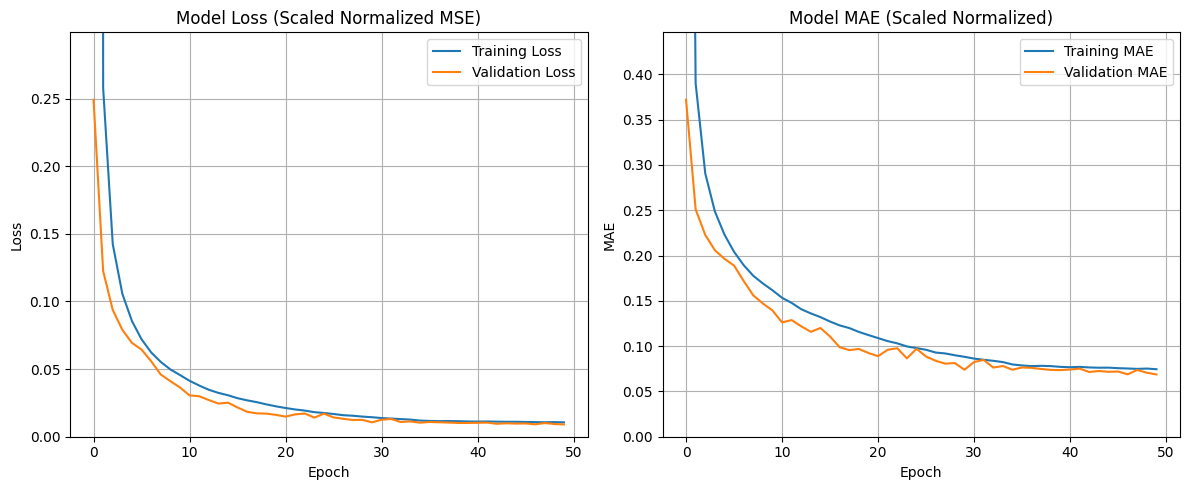


Plotting Actual vs Predicted (Actual MW Scale)...


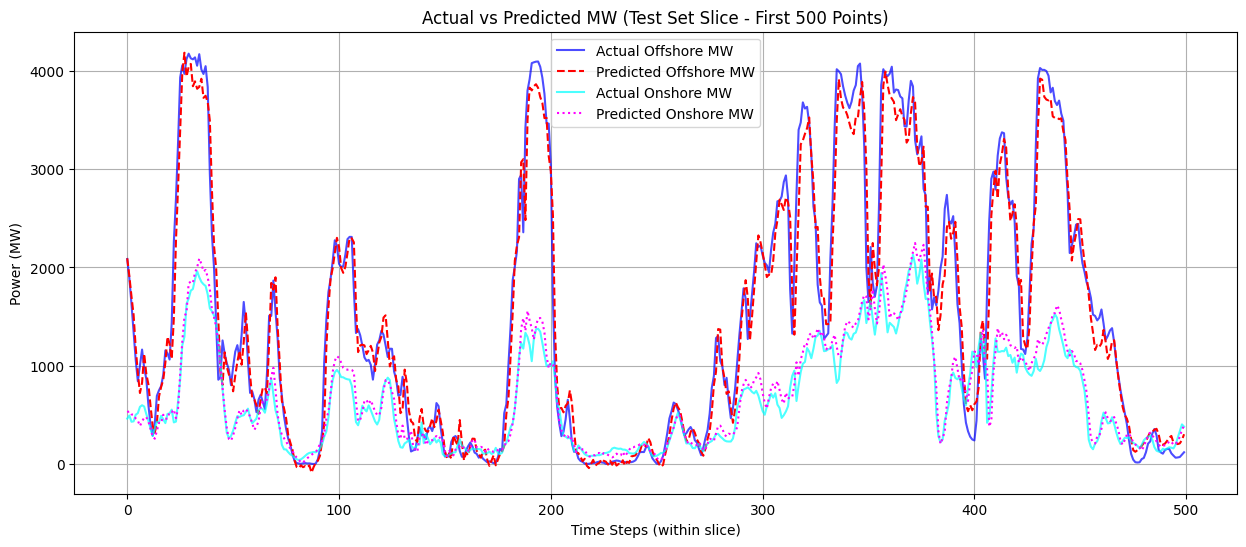

In [18]:
#  11. Plotting Results  

if 'history' in locals() and history and hasattr(history, 'history'):
    plt.figure(figsize=(12, 5))

    # Plot Loss
    if 'loss' in history.history and 'val_loss' in history.history:
        plt.subplot(1, 2, 1)
        plt.plot(history.history['loss'], label='Training Loss')
        plt.plot(history.history['val_loss'], label='Validation Loss')
        plt.title('Model Loss (Scaled Normalized MSE)') # Reflects normalized target loss
        plt.xlabel('Epoch')
        plt.ylabel('Loss')
        plt.legend()
        plt.grid(True)
        loss_max = max(history.history.get('val_loss', [0]))
        plt.ylim(bottom=0, top=min(loss_max * 1.2, 5) if loss_max > 0 else 1) 

    # Plot MAE
    if 'mae' in history.history and 'val_mae' in history.history:
        plt.subplot(1, 2, 2)
        plt.plot(history.history['mae'], label='Training MAE')
        plt.plot(history.history['val_mae'], label='Validation MAE')
        plt.title('Model MAE (Scaled Normalized)') # Reflects normalized target MAE
        plt.xlabel('Epoch')
        plt.ylabel('MAE')
        plt.legend()
        plt.grid(True)
        mae_max = max(history.history.get('val_mae', [0]))
        plt.ylim(bottom=0, top=min(mae_max * 1.2, 2) if mae_max > 0 else 1) 

    plt.tight_layout()
    plt.show() 
else:
    print("Training history object ('history') not found or is empty. Skipping learning curve plots.")


# Plot Actual vs Predicted (on Actual MW Scale) 
print("\nPlotting Actual vs Predicted (Actual MW Scale)...")
plt.figure(figsize=(15, 6))

plot_slice_len = min(500, len(actual_scale_y_test))
plot_slice = slice(0, plot_slice_len)

if len(actual_scale_y_test) > 0 and len(actual_scale_predictions) > 0 :
    # Plot Offshore
    if actual_scale_y_test.shape[1] > 0:
        plt.plot(actual_scale_y_test[plot_slice, 0], label='Actual Offshore MW', color='blue', alpha=0.7)
        plt.plot(actual_scale_predictions[plot_slice, 0], label='Predicted Offshore MW', color='red', linestyle='--')
    # Plot Onshore 
    if actual_scale_y_test.shape[1] > 1:
         plt.plot(actual_scale_y_test[plot_slice, 1], label='Actual Onshore MW', color='cyan', alpha=0.7)
         plt.plot(actual_scale_predictions[plot_slice, 1], label='Predicted Onshore MW', color='magenta', linestyle=':')

    plt.title(f'Actual vs Predicted MW (Test Set Slice - First {plot_slice.stop} Points)')
    plt.xlabel(f'Time Steps (within slice)')
    plt.ylabel('Power (MW)')
    plt.legend()
    plt.grid(True)
    plt.show() 
else:
    print("No actual or predicted data available to plot for Actual vs Predicted.")


In [24]:

# ===>>> HYPERPARAMETER PRINTING <<<===
print("\n" + "="*30)
print("=== Run Configuration Summary ===")
print("="*30)
# --- Data & Preprocessing ---
print(f"Start Date Filter:          {start_date}")         
if 'lag_hours' in locals():
    print(f"Lagged Feature Hours (H):   {lag_hours}")
else:
    print("Lagged Feature Hours (H):   Not explicitly defined in this scope (Check In[20])")
print(f"Validation Split Fraction:  {VALIDATION_SPLIT_FRAC}") 
print(f"Scaler Type:                {SCALER_TYPE}")         
print(f"Number of Input Features:   {NUM_FEATURES}")      
print(f"Number of Output Targets:   {NUM_OUTPUTS}")       
# --- Sequence & Training ---
print(f"Sequence Length:            {SEQUENCE_LENGTH}")    
print(f"Epochs:                     {EPOCHS}")            
print(f"Batch Size:                 {BATCH_SIZE}")          
print(f"Learning Rate:              {LEARNING_RATE}")       
print(f"Use LR Scheduler:           {USE_LR_SCHEDULER}")    
# --- TCN Architecture ---
print(f"TCN Filters:                {TCN_NUM_FILTERS}")   
print(f"TCN Kernel Size:            {TCN_KERNEL_SIZE}")    
print(f"TCN Stacks:                 {TCN_NUM_STACKS}")      
print(f"TCN Dilations:              {TCN_DILATIONS}")       
print(f"TCN Padding:                {PADDING}")           
print(f"TCN Activation:             {ACTIVATION}")         
print(f"TCN Dropout Rate:           {TCN_DROPOUT_RATE}")   
print(f"TCN Use Skip Connections:   {USE_SKIP_CONNECTIONS}")
print(f"TCN Return Sequences:       {RETURN_SEQUENCES}")    
# --- Regularization ---
print(f"Use L2 Regularization:      {USE_L2_REG}")         
print(f"L2 Factor:                  {L2_FACTOR if USE_L2_REG else 'N/A'}") 
print("="*30 + "\n")


#  11. Performance Evaluation Context 
print("\n--- 11. Performance Evaluation Context ---")


required_vars = ['actual_scale_y_test', 'actual_scale_predictions', 'final_df', 'X_test_df', 'SEQUENCE_LENGTH', 'X_train_df']
missing_vars = [var for var in required_vars if var not in locals()]
if missing_vars:
    print(f"Error: Missing required variables for baseline calculation: {missing_vars}")
    print("Please ensure the script has run correctly up to the end of Step 10.")


#  A. TCN Model Performance  
print("\n--- A. TCN Model Performance ---")
try:
    # Calculate MAE and RMSE 
    tcn_mae_overall = mean_absolute_error(actual_scale_y_test, actual_scale_predictions)
    tcn_mae_offshore = mean_absolute_error(actual_scale_y_test[:, 0], actual_scale_predictions[:, 0])
    tcn_mae_onshore = mean_absolute_error(actual_scale_y_test[:, 1], actual_scale_predictions[:, 1])

    tcn_rmse_overall = np.sqrt(mean_squared_error(actual_scale_y_test, actual_scale_predictions))
    tcn_rmse_offshore = np.sqrt(mean_squared_error(actual_scale_y_test[:, 0], actual_scale_predictions[:, 0]))
    tcn_rmse_onshore = np.sqrt(mean_squared_error(actual_scale_y_test[:, 1], actual_scale_predictions[:, 1]))

    print(f"TCN MAE (MW):            {tcn_mae_overall:.2f} (Offshore: {tcn_mae_offshore:.2f}, Onshore: {tcn_mae_onshore:.2f})")
    print(f"TCN RMSE (MW):           {tcn_rmse_overall:.2f} (Offshore: {tcn_rmse_offshore:.2f}, Onshore: {tcn_rmse_onshore:.2f})")
except Exception as e:
    print(f"Error calculating TCN MAE/RMSE: {e}")


# B. Baseline Comparison: Persistence Model 

print("\n--- B. Baseline Comparison: Persistence Model ---")

# Define persistence lags to test
persistence_lags = ['1H', '24H'] # 1 hour and 24 hours
target_cols_original = ['Wind_Offshore_MW', 'Wind_Onshore_MW'] # Original column names

# Dictionary to store baseline results for summary
baseline_results = {}

# Get the timestamps corresponding to the actual_scale_y_test
# Since sequence creation shifts things, we need the index of the *original* test data
# and then align it properly.
try:
    test_set_indices = X_test_df.index # Index of the original test split features

    # The actual targets correspond to the *end* of each sequence.
    # The first prediction corresponds to the target at index (SEQUENCE_LENGTH - 1) of X_test_df
    # The last prediction corresponds to the target at index (len(X_test_df) - 1)
    # Let's get the index range for the targets we actually predicted
    target_indices = test_set_indices[SEQUENCE_LENGTH - 1 : len(test_set_indices)]

    # Ensure the length matches the predictions
    if len(target_indices) != len(actual_scale_y_test):
        print(f"Warning: Length mismatch between inferred target indices ({len(target_indices)}) and actual test targets ({len(actual_scale_y_test)}). Adjusting target indices.")
        # This might happen if there were issues in sequence creation or inverse transform alignment
        target_indices = target_indices[:len(actual_scale_y_test)] # Adjust index length


    # Get the actual ground truth values using these indices from the original final_df
    y_test_actual_mw_for_baseline = final_df.loc[target_indices, target_cols_original]


    for lag in persistence_lags:
        print(f"\nCalculating Persistence Baseline (Lag: {lag})...")
        try:
            # Need data from before the test set starts for the lookback
            # Find the start time needed for the lag
            start_time_needed = target_indices.min() - pd.Timedelta(lag)
            # Get data including the lookback period
            persistence_data = final_df.loc[start_time_needed:, target_cols_original]
            # Create lagged predictions
            persistence_preds_shifted = persistence_data.shift(freq=lag)
            # Align predictions with the actual test targets
            persistence_preds_aligned = persistence_preds_shifted.loc[target_indices]

            # Drop NaNs resulting from the shift (at the beginning)
            valid_indices = persistence_preds_aligned.dropna().index
            persistence_preds_final = persistence_preds_aligned.loc[valid_indices]
            y_test_actual_aligned = y_test_actual_mw_for_baseline.loc[valid_indices]

            if len(persistence_preds_final) == 0:
                print(f"Error: No valid persistence predictions for lag {lag}. Check data range and lag.")
                baseline_results[f'Persistence_{lag}'] = {'mae': np.nan, 'rmse': np.nan}
                continue

            # Calculate metrics 
            mae_persistence = mean_absolute_error(y_test_actual_aligned, persistence_preds_final)
            rmse_persistence = np.sqrt(mean_squared_error(y_test_actual_aligned, persistence_preds_final))

            print(f"Persistence ({lag}) MAE (MW): {mae_persistence:.2f}")
            print(f"Persistence ({lag}) RMSE (MW): {rmse_persistence:.2f}")

            # Store results
            baseline_results[f'Persistence_{lag}'] = {'mae': mae_persistence, 'rmse': rmse_persistence}


        except Exception as e:
            print(f"Error calculating persistence baseline for lag {lag}: {e}")
            baseline_results[f'Persistence_{lag}'] = {'mae': np.nan, 'rmse': np.nan}

except KeyError as e:
     print(f"KeyError accessing DataFrame index or columns for baseline: {e}")
     print("Skipping baseline calculations.")
except Exception as e:
     print(f"An unexpected error occurred during baseline setup: {e}")
     print("Skipping baseline calculations.")


# C. Baseline Comparison: Simple Average Model 

print("\n--- C. Baseline Comparison: Simple Average Model ---")

# Get the indices for the original training set 
if 'X_train_df' in locals() and not X_train_df.empty:
    train_set_indices = X_train_df.index

    try:
        # Calculate the mean of the targets *only from the training period*
        train_targets_actual_mw = final_df.loc[train_set_indices, target_cols_original]
        train_mean_offshore = train_targets_actual_mw['Wind_Offshore_MW'].mean()
        train_mean_onshore = train_targets_actual_mw['Wind_Onshore_MW'].mean()

        # Create predictions for the test set (same mean value for all test points)
        if 'y_test_actual_mw_for_baseline' in locals() and not y_test_actual_mw_for_baseline.empty:
            avg_preds_offshore = np.full(len(y_test_actual_mw_for_baseline), train_mean_offshore)
            avg_preds_onshore = np.full(len(y_test_actual_mw_for_baseline), train_mean_onshore)
            avg_preds = np.stack([avg_preds_offshore, avg_preds_onshore], axis=1)

            # Calculate metrics 
            mae_average = mean_absolute_error(y_test_actual_mw_for_baseline, avg_preds)
            rmse_average = np.sqrt(mean_squared_error(y_test_actual_mw_for_baseline, avg_preds))

            print(f"Simple Avg MAE (MW): {mae_average:.2f}")
            print(f"Simple Avg RMSE (MW): {rmse_average:.2f}")

            # Store results
            baseline_results['Simple_Average'] = {'mae': mae_average, 'rmse': rmse_average}

        else:
             print("Error: y_test_actual_mw_for_baseline not available for Simple Average calculation.")
             baseline_results['Simple_Average'] = {'mae': np.nan, 'rmse': np.nan}


    except KeyError as e:
        print(f"KeyError calculating simple average baseline (check train_set_indices or target_cols_original): {e}")
        baseline_results['Simple_Average'] = {'mae': np.nan, 'rmse': np.nan}
    except Exception as e:
        print(f"Error calculating simple average baseline: {e}")
        baseline_results['Simple_Average'] = {'mae': np.nan, 'rmse': np.nan}
else:
     print("X_train_df not found or empty. Skipping Simple Average baseline.")
     baseline_results['Simple_Average'] = {'mae': np.nan, 'rmse': np.nan}


print("\n--- Baseline Calculations Complete ---")

# D. Summary Comparison 
print("\n--- D. Performance Summary ---")
print(f"{'Metric':<15} | {'TCN Model':<15} | {'Persistence (1H)':<17} | {'Persistence (24H)':<18} | {'Simple Average':<15}")
print(f"----------------|-----------------|-------------------|--------------------|-----------------")

# Retrieve stored results safely using .get() with default np.nan
pers_1h_mae = baseline_results.get('Persistence_1H', {}).get('mae', np.nan)
pers_1h_rmse = baseline_results.get('Persistence_1H', {}).get('rmse', np.nan)
pers_24h_mae = baseline_results.get('Persistence_24H', {}).get('mae', np.nan)
pers_24h_rmse = baseline_results.get('Persistence_24H', {}).get('rmse', np.nan)
avg_mae = baseline_results.get('Simple_Average', {}).get('mae', np.nan)
avg_rmse = baseline_results.get('Simple_Average', {}).get('rmse', np.nan)

tcn_mae_overall = tcn_mae_overall if 'tcn_mae_overall' in locals() else np.nan
tcn_rmse_overall = tcn_rmse_overall if 'tcn_rmse_overall' in locals() else np.nan


print(f"{'MAE (MW)':<15} | {tcn_mae_overall:<15.2f} | {pers_1h_mae:<17.2f} | {pers_24h_mae:<18.2f} | {avg_mae:<15.2f}")
print(f"{'RMSE (MW)':<15} | {tcn_rmse_overall:<15.2f} | {pers_1h_rmse:<17.2f} | {pers_24h_rmse:<18.2f} | {avg_rmse:<15.2f}")


=== Run Configuration Summary ===
Start Date Filter:          2022-01-01
Lagged Feature Hours (H):   1
Validation Split Fraction:  0.2
Scaler Type:                RobustScaler
Number of Input Features:   21
Number of Output Targets:   2
Sequence Length:            24
Epochs:                     50
Batch Size:                 64
Learning Rate:              0.0005
Use LR Scheduler:           True
TCN Filters:                16
TCN Kernel Size:            12
TCN Stacks:                 4
TCN Dilations:              [1, 2, 4, 8, 16]
TCN Padding:                causal
TCN Activation:             relu
TCN Dropout Rate:           0.3
TCN Use Skip Connections:   True
TCN Return Sequences:       False
Use L2 Regularization:      True
L2 Factor:                  0.005


--- 11. Performance Evaluation Context ---
Error: Missing required variables for baseline calculation: ['actual_scale_y_test', 'actual_scale_predictions', 'final_df', 'X_test_df', 'SEQUENCE_LENGTH', 'X_train_df']
Please ensure t